
# Multi-Agent Reinforcement Learning (MARL) with TorchRL


In this project, you will implement and analyze two foundational algorithms in Multi-Agent Reinforcement Learning (MARL):
- [MADDPG (Multi-Agent Deep Deterministic Policy Gradient)](https://arxiv.org/abs/1706.02275)
- [MAPPO (Multi-Agent Proximal Policy Optimization)](https://arxiv.org/abs/2103.01955)

Both algorithms will be tested in the VMAS (Vectorized Multi-Agent Simulator) navigation environment, where multiple agents must learn to coordinate in a shared space.


In [ ]:
!pip3 install torchrl
!pip3 install vmas
!pip3 install tqdm
!apt-get update -y
!apt-get install -y x11-utils xvfb python3-opengl libgl1-mesa-glx libglu1-mesa
!pip install pyvirtualdisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.5/559.5 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.6 MB/s eta 0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260251 sha256=9c973aa75929c6f946efe9a6314e8479aeaa8da7417bf801aac82dcd71b87b78
  Stored in directory: /root/.cache/pip/wheels/a7/6f/80/31791456a87da225991ef3a80730ff89d3b96fe30ffba64d3a
Successfully built vmas
  Attempting uninstall: gym-notices
    Found existing installation: gym-notices 0.1.0
    Uninstalling gym-notices-0.1.0:
      Successfully uninstalled gym-notices-0.1.0
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [

In [2]:
# Torch
import torch

# Tensordict modules
from tensordict import TensorDictBase
from tensordict.nn import set_composite_lp_aggregate, TensorDictModule, TensorDictSequential
from tensordict.nn.distributions import NormalParamExtractor
from torch import multiprocessing

# Data collection
from torchrl.collectors import Collector
from torchrl.data.replay_buffers import LazyMemmapStorage, RandomSampler, ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage

# Env
from torchrl.envs import RewardSum, TransformedEnv
from torchrl.envs.libs.vmas import VmasEnv
from torchrl.envs.utils import check_env_specs

# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor, AdditiveGaussianModule, TanhNormal, TanhDelta

# Loss
from torchrl.objectives import ClipPPOLoss, DDPGLoss, SoftUpdate, ValueEstimators

# Utils
torch.manual_seed(0)
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import tempfile
from matplotlib import pyplot as plt


## Hyperparameters



In [3]:
# Devices
is_fork = multiprocessing.get_start_method() == "fork"
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 6_000
n_iters = 500  # Number of training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 30  # Number of optimization steps per training iteration
minibatch_size = 400  # Size of the mini-batches in each optimization step
lr = 3e-4
max_grad_norm = 1.0  # Maximum norm for the gradients

gamma = 0.99  # discount factor

# DDPG Algorithm
polyak_tau = 0.005
memory_size=1_000_000

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

# disable log-prob aggregation
set_composite_lp_aggregate(False).set()

## Environment

We use the VMAS Navigation environment, a vectorized multi-agent simulator.
It runs many environments in parallel on the GPU, where each agent:
- observes its local state
- selects continuous actions
- receives individual rewards



In [4]:
max_steps = 100
num_vmas_envs = (
    frames_per_batch // max_steps
)
scenario_name = "navigation"
n_agents = 3

env = VmasEnv(
    scenario=scenario_name,
    num_envs=num_vmas_envs,
    continuous_actions=True,
    max_steps=max_steps,
    device=vmas_device,
    n_agents=n_agents,
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: Composite(
    agents: Composite(
        action: BoundedContinuous(
            shape=torch.Size([60, 3, 2]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, contiguous=True)),
            device=cuda:0,
            dtype=torch.float32,
            domain=continuous),
        device=cuda:0,
        shape=torch.Size([60, 3]),
        data_cls=None),
    device=cuda:0,
    shape=torch.Size([60]),
    data_cls=None)
reward_spec: Composite(
    agents: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([60, 3, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True

In [6]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('agents', 'action')]
reward_keys: [('agents', 'reward')]
done_keys: ['done', 'terminated']


In [7]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("agents", "episode_reward")]),
)

In [8]:
check_env_specs(env)

2026-08-18 20:26:50,820 [torchrl][INFO]    check_env_specs succeeded! [END]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
n_rollout_steps = 5
rollout = env.rollout(n_rollout_steps)
print("rollout of three steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)

rollout of three steps: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 5, 3, 2]), device=cuda:0, dtype=torch.float32, is_shared=True),
                episode_reward: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        final_rew: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        pos_rew: Tensor(shape=torch.Size([60, 5, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True)},
                    batch_size=torch.Size([60, 5, 3]),
                    device=cuda:0,
                    is_shared=True),
                observation: Tensor(shape=torch.Size([60, 5, 3, 18]), device=cud

# MADDPG


## Policy

In MADDPG, each agent learns a **deterministic policy** that maps its local observation directly to a continuous action. This actor is implemented as a shared MLP across agents, which promotes parameter sharing and improves sample efficiency by allowing agents to benefit from each other’s experience. Since actions must lie within bounded ranges, the raw network outputs are passed through a `tanh`-based transformation (e.g., `TanhDelta`) to ensure they stay within the valid action space.

Because the policy is deterministic, exploration is not inherent in the network and is instead introduced by adding Gaussian noise to the actions during training. This follows the MADDPG idea of combining stable deterministic policies with explicit exploration noise, enabling agents to explore the environment while still learning a smooth continuous control policy.


In [10]:
share_parameters_policy = True

policy_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["agents", "observation"].shape[
        -1
    ],  # n_obs_per_agent
    n_agent_outputs=env.full_action_spec["agents", "action"].shape[
        -1
    ],  # n_actions_per_agents
    n_agents=n_agents,
    centralised=False,  # the policies are decentralised
    share_params=share_parameters_policy,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(


In [11]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "param")],
)

In [12]:
# Deterministic decentralized actor used by MADDPG.
# Exploration noise is added separately in `exploration_policy`.
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.full_action_spec["agents", "action"],
    in_keys=[("agents", "param")],
    out_keys=[("agents", "action")],
    distribution_class=TanhDelta,
    distribution_kwargs={
        "low": env.full_action_spec_unbatched["agents", "action"].space.low,
        "high": env.full_action_spec_unbatched["agents", "action"].space.high,
    },
    return_log_prob=False,
)


In [16]:
exploration_policy = TensorDictSequential(
        policy,
        AdditiveGaussianModule(
            spec=policy.spec,
            annealing_num_steps=total_frames
            // 2,  # Number of frames after which sigma is sigma_end
            action_key=env.action_key,
            sigma_init=0.5,  # Initial value of the sigma
            sigma_end=0.5,  # Final value of the sigma
        ),
)

## Critic network
In MADDPG, the critic is **centralized during training**, meaning it receives the concatenated observations and actions of all agents. This allows it to estimate a joint action-value function \( Q(s, a_1, ..., a_n) \), capturing interactions between agents that are not visible locally.

This centralized design improves training stability by reducing non-stationarity, while agents still execute policies **decentrally using only local observations**, following the CTDE paradigm.


In [13]:
share_parameters_critic = True
MADDPG = True  # Set False for IDDPG (decentralized critic)

# Concatenate each agent's local observation and action before passing
# the resulting per-agent features to MultiAgentMLP. With
# `centralised=True`, MultiAgentMLP then conditions each Q estimate on
# the joint features of all agents.
cat_module = TensorDictModule(
    module=lambda obs, action: torch.cat([obs, action], dim=-1),
    in_keys=[("agents", "observation"), ("agents", "action")],
    out_keys=[("agents", "obs_action")],
)

critic_module = TensorDictModule(
    module=MultiAgentMLP(
        n_agent_inputs=env.observation_spec["agents", "observation"].shape[-1]
        + env.full_action_spec["agents", "action"].shape[-1],
        n_agent_outputs=1,
        n_agents=n_agents,
        centralised=MADDPG,
        share_params=share_parameters_critic,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    ),
    in_keys=[("agents", "obs_action")],
    out_keys=[("agents", "state_action_value")],
)

critic = TensorDictSequential(cat_module, critic_module)


In [14]:
# Verify CTDE tensor shapes.
with torch.no_grad():
    td0 = env.reset()
    td_actor = policy(td0.clone())
    td_critic = critic(td_actor.clone())

obs_dim = env.observation_spec["agents", "observation"].shape[-1]
act_dim = env.full_action_spec["agents", "action"].shape[-1]

print("MADDPG / IDDPG mode:", "MADDPG" if MADDPG else "IDDPG")
print("Local observation tensor:", td0.get(("agents", "observation")).shape)
print("Action tensor:", td_actor.get(("agents", "action")).shape)
print("Per-agent obs-action tensor:", td_critic.get(("agents", "obs_action")).shape)
print("Critic output tensor:", td_critic.get(("agents", "state_action_value")).shape)
print("Actor features visible per execution:", obs_dim)
print(
    "Critic effective training input features:",
    n_agents * (obs_dim + act_dim) if MADDPG else (obs_dim + act_dim),
)


MADDPG / IDDPG mode: MADDPG
Local observation tensor: torch.Size([60, 3, 18])
Action tensor: torch.Size([60, 3, 2])
Per-agent obs-action tensor: torch.Size([60, 3, 20])
Critic output tensor: torch.Size([60, 3, 1])
Actor features visible per execution: 18
Critic effective training input features: 60


## Data collector


In [17]:
collector = Collector(
    env,
    exploration_policy,
    device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

/tmp/ipykernel_1210/114081068.py:1: FutureWarning: The env passed to Collector is missing transforms required by the policy (InitTracker). From torchrl v0.15 the collector will append them automatically. To enable that behavior now (and silence this warning), pass `auto_register_policy_transforms=True`. To opt out permanently, pass `auto_register_policy_transforms=False`.
  collector = Collector(


## Replay buffer


In [18]:
scratch_dir = tempfile.TemporaryDirectory().name
replay_buffer = ReplayBuffer(
    storage=LazyMemmapStorage(
        memory_size,
        scratch_dir=scratch_dir,
    ),  # store up to memory_size multi-agent transitions
    sampler=RandomSampler(),
    batch_size=minibatch_size,  # sample batches of this size
)
if device.type != "cpu":
    replay_buffer.append_transform(lambda x: x.to(device))

## Loss function

The DDPG loss consists of:
- Actor loss: improves policy using critic feedback
- Critic loss: fits Q-values using TD targets

Target networks and soft updates stabilize training.


In [19]:
loss_module = DDPGLoss(
    actor_network=policy,  # Use the non-explorative policies
    value_network=critic,
    delay_value=True,  # Whether to use a target network for the value
    loss_function="l2",
)
loss_module.set_keys(
    state_action_value=("agents", "state_action_value"),
    reward=("agents", "reward"),
    done=("agents", "done"),
    terminated=("agents", "terminated"),
)
loss_module.make_value_estimator(ValueEstimators.TD0, gamma=gamma)

In [20]:
target_updater = SoftUpdate(loss_module, tau=polyak_tau)

In [21]:
optimisers = {
        "loss_actor": torch.optim.Adam(
            loss_module.actor_network_params.flatten_keys().values(), lr=lr
        ),
        "loss_value": torch.optim.Adam(
            loss_module.value_network_params.flatten_keys().values(), lr=lr
        ),
    }

## Training Loop


In [ ]:
reward_key = env.reward_key
done_key = ("next", "done")
terminated_key = ("next", "terminated")

pbar = tqdm(total=n_iters, desc="Training MADDPG...")
episode_reward_mean_list = []

maddpg_history = {
    "frames": [],
    "episode_reward": [],
    "loss_actor": [],
    "loss_value": [],
    "actor_grad_norm": [],
    "critic_grad_norm": [],
    "exploration_sigma": [],
}
frames_seen = 0

for tensordict_data in collector:
    current_frames = tensordict_data.numel()
    frames_seen += current_frames
    reward_shape = tensordict_data.get_item_shape(("next", reward_key))

    # DDPGLoss expects per-agent done/terminated entries with the
    # same shape as the per-agent reward.
    tensordict_data.set(
        ("next", "agents", "done"),
        tensordict_data.get(done_key).unsqueeze(-1).expand(reward_shape),
    )
    tensordict_data.set(
        ("next", "agents", "terminated"),
        tensordict_data.get(terminated_key).unsqueeze(-1).expand(reward_shape),
    )

    # Off-policy replay: keep collected transitions and reuse them.
    replay_buffer.extend(tensordict_data.reshape(-1))

    actor_losses = []
    critic_losses = []
    actor_grad_norms = []
    critic_grad_norms = []

    if len(replay_buffer) >= minibatch_size:
        for _ in range(num_epochs):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            actor_loss = loss_vals["loss_actor"]
            critic_loss = loss_vals["loss_value"]
            total_loss = actor_loss + critic_loss

            total_loss.backward()

            actor_params = optimisers["loss_actor"].param_groups[0]["params"]
            critic_params = optimisers["loss_value"].param_groups[0]["params"]
            actor_grad_norm = torch.nn.utils.clip_grad_norm_(
                actor_params, max_grad_norm
            )
            critic_grad_norm = torch.nn.utils.clip_grad_norm_(
                critic_params, max_grad_norm
            )

            optimisers["loss_actor"].step()
            optimisers["loss_value"].step()
            optimisers["loss_actor"].zero_grad(set_to_none=True)
            optimisers["loss_value"].zero_grad(set_to_none=True)

            # Slowly move target-network parameters toward online parameters.
            target_updater.step()

            actor_losses.append(actor_loss.detach().item())
            critic_losses.append(critic_loss.detach().item())
            actor_grad_norms.append(float(actor_grad_norm.detach().cpu()))
            critic_grad_norms.append(float(critic_grad_norm.detach().cpu()))

    # Update the Gaussian exploration schedule after collecting the batch.
    exploration_policy[-1].step(current_frames)
    exploration_sigma = float(exploration_policy[-1].sigma.detach().cpu())

    done = tensordict_data.get(("next", "agents", "done"))
    if done.any():
        episode_reward_mean = (
            tensordict_data.get(("next", "agents", "episode_reward"))[done]
            .mean()
            .item()
        )
    else:
        episode_reward_mean = float("nan")

    episode_reward_mean_list.append(episode_reward_mean)

    maddpg_history["frames"].append(frames_seen)
    maddpg_history["episode_reward"].append(episode_reward_mean)
    maddpg_history["loss_actor"].append(
        sum(actor_losses) / len(actor_losses) if actor_losses else float("nan")
    )
    maddpg_history["loss_value"].append(
        sum(critic_losses) / len(critic_losses) if critic_losses else float("nan")
    )
    maddpg_history["actor_grad_norm"].append(
        sum(actor_grad_norms) / len(actor_grad_norms)
        if actor_grad_norms
        else float("nan")
    )
    maddpg_history["critic_grad_norm"].append(
        sum(critic_grad_norms) / len(critic_grad_norms)
        if critic_grad_norms
        else float("nan")
    )
    maddpg_history["exploration_sigma"].append(exploration_sigma)

    pbar.set_description(
        "MADDPG | "
        f"return={episode_reward_mean:.2f} "
        f"Qloss={maddpg_history['loss_value'][-1]:.3f} "
        f"sigma={exploration_sigma:.3f}",
        refresh=False,
    )
    pbar.update()

pbar.close()


Training MADDPG...:   0%|          | 0/500 [00:00<?, ?it/s]

2026-08-18 12:40:30,014 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([1000000]) shape [END]


MADDPG | return=2.67 Qloss=0.015 sigma=0.500: 100%|██████████| 500/500 [17:05<00:00,  2.05s/it]


## Results


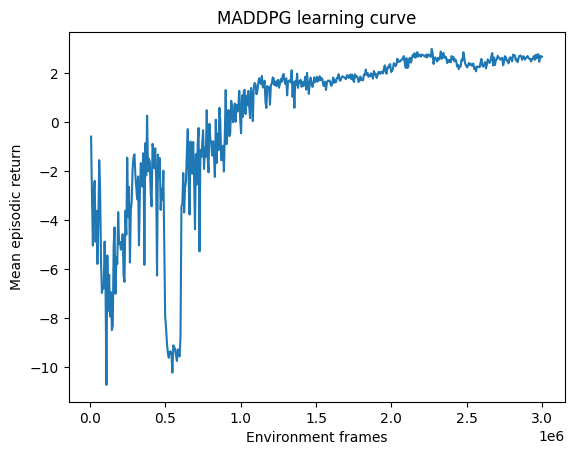

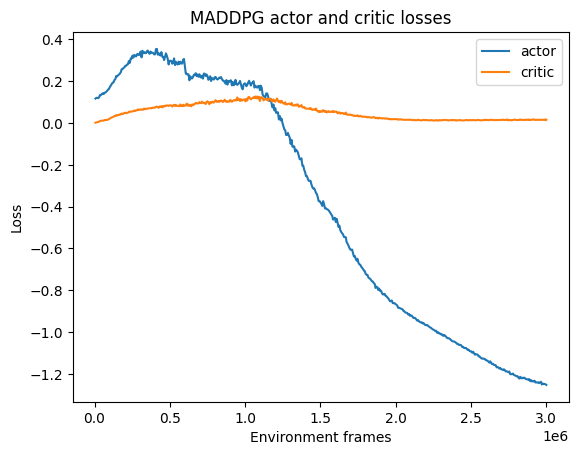

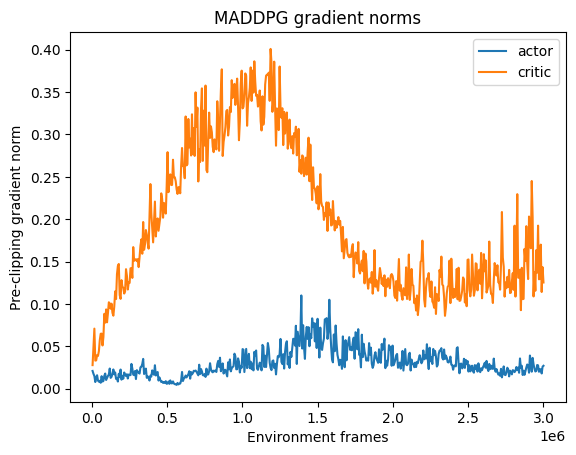

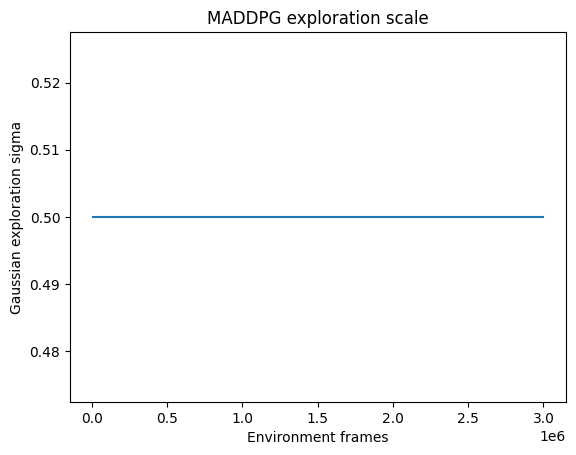

In [ ]:
plt.plot(maddpg_history["frames"], maddpg_history["episode_reward"])
plt.xlabel("Environment frames")
plt.ylabel("Mean episodic return")
plt.title("MADDPG learning curve")
plt.show()

plt.plot(maddpg_history["frames"], maddpg_history["loss_actor"], label="actor")
plt.plot(maddpg_history["frames"], maddpg_history["loss_value"], label="critic")
plt.xlabel("Environment frames")
plt.ylabel("Loss")
plt.title("MADDPG actor and critic losses")
plt.legend()
plt.show()

plt.plot(maddpg_history["frames"], maddpg_history["actor_grad_norm"], label="actor")
plt.plot(maddpg_history["frames"], maddpg_history["critic_grad_norm"], label="critic")
plt.xlabel("Environment frames")
plt.ylabel("Pre-clipping gradient norm")
plt.title("MADDPG gradient norms")
plt.legend()
plt.show()

plt.plot(maddpg_history["frames"], maddpg_history["exploration_sigma"])
plt.xlabel("Environment frames")
plt.ylabel("Gaussian exploration sigma")
plt.title("MADDPG exploration scale")
plt.show()


## Render


/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacin

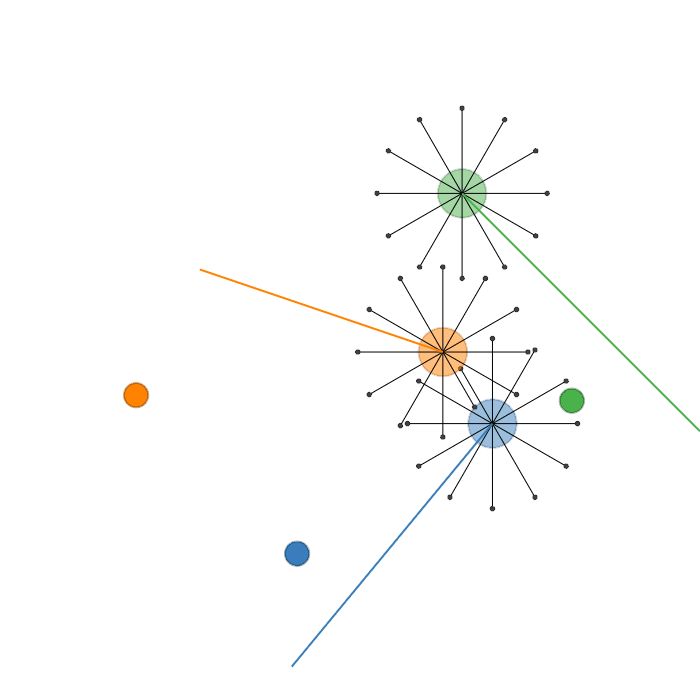

In [ ]:
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()
from PIL import Image

def rendering_callback(env, td):
    env.frames.append(Image.fromarray(env.render(mode="rgb_array")))
env.frames = []
with torch.no_grad():
   env.rollout(
       max_steps=max_steps,
       policy=policy,
       callback=rendering_callback,
       auto_cast_to_device=True,
       break_when_any_done=False,
   )
env.frames[0].save(
    f"{scenario_name}.gif",
    save_all=True,
    append_images=env.frames[1:],
   duration=3,
   loop=0,
)

from IPython.display import Image
Image(open(f"{scenario_name}.gif", "rb").read())

# MAPPO


## Hyperparameters


In [22]:
frames_per_batch = 6_000
n_iters = 20
total_frames = frames_per_batch * n_iters

## Environment


In [23]:
max_steps = 100
num_vmas_envs = frames_per_batch // max_steps
scenario_name = "navigation"
n_agents = 3

env = VmasEnv(
    scenario=scenario_name,
    num_envs=num_vmas_envs,
    continuous_actions=True,
    max_steps=max_steps,
    device=vmas_device,
    n_agents=n_agents,
)


In [24]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("agents", "episode_reward")]),
)

## Policy
In MAPPO, the policy is stochastic and outputs the parameters of a Gaussian distribution (mean and standard deviation), from which actions are sampled using a squashed distribution like TanhNormal to ensure valid action bounds.


In [25]:
share_parameters_policy = True

policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=env.observation_spec["agents", "observation"].shape[
            -1
        ],  # n_obs_per_agent
        n_agent_outputs=2
        * env.full_action_spec[env.action_key].shape[-1],  # 2 * n_actions_per_agents
        n_agents=env.n_agents,
        centralised=False,  # the policies are decentralised
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    ),
    NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

In [26]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "loc"), ("agents", "scale")],
)

In [27]:
# Stochastic decentralized actor used by MAPPO/IPPO.
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec_unbatched,
    in_keys=[("agents", "loc"), ("agents", "scale")],
    out_keys=[env.action_key],
    distribution_class=TanhNormal,
    distribution_kwargs={
        "low": env.full_action_spec_unbatched[env.action_key].space.low,
        "high": env.full_action_spec_unbatched[env.action_key].space.high,
    },
    return_log_prob=True,
)


## Critic network
In MAPPO, the critic estimates the state-value function for each agent using centralized observations. It is used to compute advantage estimates via GAE (Generalized Advantage Estimation), which helps reduce variance and stabilize policy updates during PPO training.


In [28]:
share_parameters_critic = True
mappo = True  # IPPO if False

critic_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["agents", "observation"].shape[-1],
    n_agent_outputs=1,  # 1 value per agent
    n_agents=env.n_agents,
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

critic = TensorDictModule(
    module=critic_net,
    in_keys=[("agents", "observation")],
    out_keys=[("agents", "state_value")],
)

In [29]:
print("Running policy:", policy(env.reset()))
print("Running value:", critic(env.reset()))

Running policy: TensorDict(
    fields={
        agents: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([60, 3, 2]), device=cuda:0, dtype=torch.float32, is_shared=True),
                action_log_prob: Tensor(shape=torch.Size([60, 3]), device=cuda:0, dtype=torch.float32, is_shared=True),
                episode_reward: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                info: TensorDict(
                    fields={
                        agent_collisions: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        final_rew: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                        pos_rew: Tensor(shape=torch.Size([60, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True)},
                    batch_size=torch.Size([60, 3]),
                    device=cuda:0,
                    is_

## Data collector




In [30]:
collector = Collector(
    env,
    policy,
    device=vmas_device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

/tmp/ipykernel_1210/878882941.py:1: FutureWarning: The env passed to Collector is missing transforms required by the policy (InitTracker). From torchrl v0.15 the collector will append them automatically. To enable that behavior now (and silence this warning), pass `auto_register_policy_transforms=True`. To opt out permanently, pass `auto_register_policy_transforms=False`.
  collector = Collector(


## Replay buffer



In [31]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),  # store the frames_per_batch collected at each iteration
    sampler=SamplerWithoutReplacement(),
    batch_size=minibatch_size,  # sample minibatches of this size
)

## Loss function

PPO optimizes a clipped objective composed of:
- policy loss (improves actions while staying close to old policy)
- value loss (critic accuracy)
- entropy bonus (encourages exploration)

Advantage normalization is disabled across agents to preserve multi-agent structure.



In [32]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coeff=entropy_eps,
    normalize_advantage=False,
)

loss_module.set_keys(
    reward=env.reward_key,
    action=env.action_key,
    value=("agents", "state_value"),
    done=("agents", "done"),
    terminated=("agents", "terminated"),
)

loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)
GAE = loss_module.value_estimator

optim = torch.optim.Adam(loss_module.parameters(), lr)


## Training loop






In [ ]:
pbar = tqdm(total=n_iters, desc="Training MAPPO...")

episode_reward_mean_list = []
mappo_history = {
    "frames": [],
    "episode_reward": [],
    "loss_objective": [],
    "loss_critic": [],
    "loss_entropy": [],
    "grad_norm": [],
    "kl_approx": [],
    "entropy": [],
}
frames_seen = 0

for iteration, tensordict_data in enumerate(collector):
    current_frames = tensordict_data.numel()
    frames_seen += current_frames

    # GAE expects done/terminated flags expanded to the per-agent reward shape.
    reward_shape = tensordict_data.get_item_shape(("next", env.reward_key))
    tensordict_data.set(
        ("next", "agents", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(reward_shape),
    )
    tensordict_data.set(
        ("next", "agents", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(reward_shape),
    )

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )

    # Print the required PPO/GAE tensor shapes once.
    if iteration == 0:
        print("MAPPO / IPPO mode:", "MAPPO" if mappo else "IPPO")
        print("action shape:", tensordict_data.get(env.action_key).shape)
        print(
            "action log-prob shape:",
            tensordict_data.get(policy.log_prob_keys[0]).shape,
        )
        print(
            "state value shape:",
            tensordict_data.get(loss_module.tensor_keys.value).shape,
        )
        print(
            "advantage shape:",
            tensordict_data.get(loss_module.tensor_keys.advantage).shape,
        )
        print(
            "value target / return shape:",
            tensordict_data.get(loss_module.tensor_keys.value_target).shape,
        )

    # On-policy replay buffer: it stores only the current collected batch.
    replay_buffer.extend(tensordict_data.reshape(-1))

    objective_losses = []
    critic_losses = []
    entropy_losses = []
    grad_norms = []
    kl_values = []
    entropy_values = []

    for _ in range(num_epochs):
        for _ in range(frames_per_batch // minibatch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )
            optim.step()
            optim.zero_grad(set_to_none=True)

            objective_losses.append(loss_vals["loss_objective"].detach().item())
            critic_losses.append(loss_vals["loss_critic"].detach().item())
            entropy_losses.append(loss_vals["loss_entropy"].detach().item())
            grad_norms.append(float(grad_norm.detach().cpu()))

            # ClipPPOLoss exposes these diagnostics in recent TorchRL versions.
            if "kl_approx" in loss_vals.keys():
                kl_values.append(loss_vals["kl_approx"].detach().mean().item())
            if "entropy" in loss_vals.keys():
                entropy_values.append(loss_vals["entropy"].detach().mean().item())

    # The collector owns a copy of the policy; synchronize it after updates.
    collector.update_policy_weights_()

    done = tensordict_data.get(("next", "agents", "done"))
    if done.any():
        episode_reward_mean = (
            tensordict_data.get(("next", "agents", "episode_reward"))[done]
            .mean()
            .item()
        )
    else:
        episode_reward_mean = float("nan")

    episode_reward_mean_list.append(episode_reward_mean)

    mappo_history["frames"].append(frames_seen)
    mappo_history["episode_reward"].append(episode_reward_mean)
    mappo_history["loss_objective"].append(
        sum(objective_losses) / len(objective_losses)
    )
    mappo_history["loss_critic"].append(sum(critic_losses) / len(critic_losses))
    mappo_history["loss_entropy"].append(
        sum(entropy_losses) / len(entropy_losses)
    )
    mappo_history["grad_norm"].append(sum(grad_norms) / len(grad_norms))
    mappo_history["kl_approx"].append(
        sum(kl_values) / len(kl_values) if kl_values else float("nan")
    )
    mappo_history["entropy"].append(
        sum(entropy_values) / len(entropy_values)
        if entropy_values
        else float("nan")
    )

    pbar.set_description(
        "MAPPO | "
        f"return={episode_reward_mean:.2f} "
        f"KL={mappo_history['kl_approx'][-1]:.4f} "
        f"entropy={mappo_history['entropy'][-1]:.3f}",
        refresh=False,
    )
    pbar.update()

pbar.close()


Training MAPPO...:   0%|          | 0/20 [00:00<?, ?it/s]

MAPPO / IPPO mode: MAPPO
action shape: torch.Size([60, 100, 3, 2])
action log-prob shape: torch.Size([60, 100, 3])
state value shape: torch.Size([60, 100, 3, 1])
advantage shape: torch.Size([60, 100, 3, 1])
value target / return shape: torch.Size([60, 100, 3, 1])
2026-08-18 13:01:46,716 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([6000]) shape [END]


MAPPO | return=2.95 KL=0.0085 entropy=0.495: 100%|██████████| 20/20 [02:02<00:00,  6.11s/it]


## Results




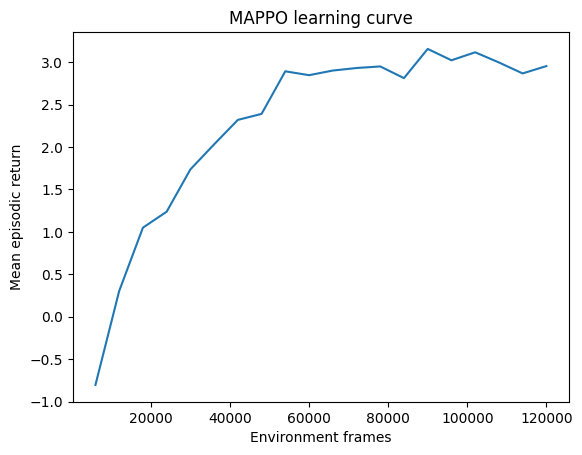

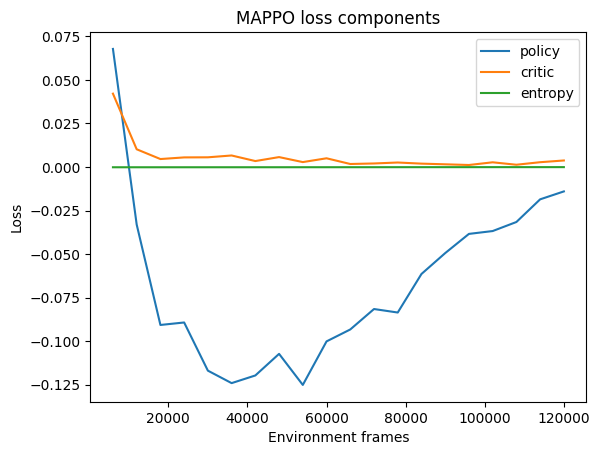

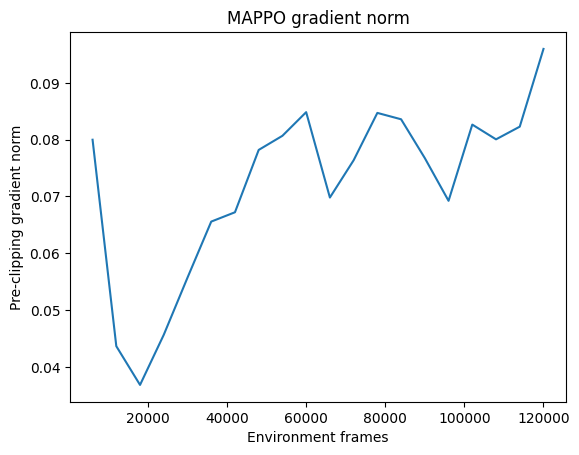

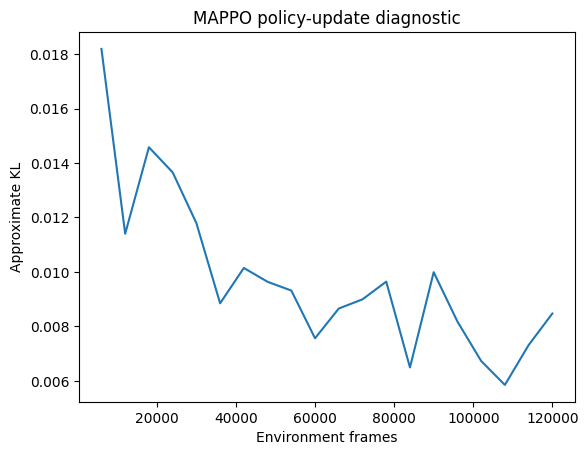

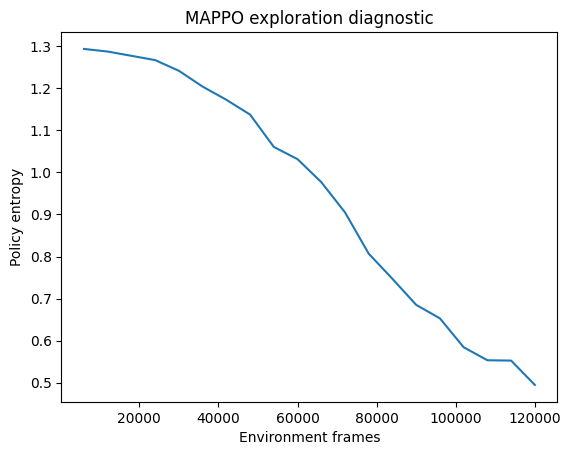

In [ ]:
plt.plot(mappo_history["frames"], mappo_history["episode_reward"])
plt.xlabel("Environment frames")
plt.ylabel("Mean episodic return")
plt.title("MAPPO learning curve")
plt.show()

plt.plot(mappo_history["frames"], mappo_history["loss_objective"], label="policy")
plt.plot(mappo_history["frames"], mappo_history["loss_critic"], label="critic")
plt.plot(mappo_history["frames"], mappo_history["loss_entropy"], label="entropy")
plt.xlabel("Environment frames")
plt.ylabel("Loss")
plt.title("MAPPO loss components")
plt.legend()
plt.show()

plt.plot(mappo_history["frames"], mappo_history["grad_norm"])
plt.xlabel("Environment frames")
plt.ylabel("Pre-clipping gradient norm")
plt.title("MAPPO gradient norm")
plt.show()

plt.plot(mappo_history["frames"], mappo_history["kl_approx"])
plt.xlabel("Environment frames")
plt.ylabel("Approximate KL")
plt.title("MAPPO policy-update diagnostic")
plt.show()

plt.plot(mappo_history["frames"], mappo_history["entropy"])
plt.xlabel("Environment frames")
plt.ylabel("Policy entropy")
plt.title("MAPPO exploration diagnostic")
plt.show()


## Render


/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


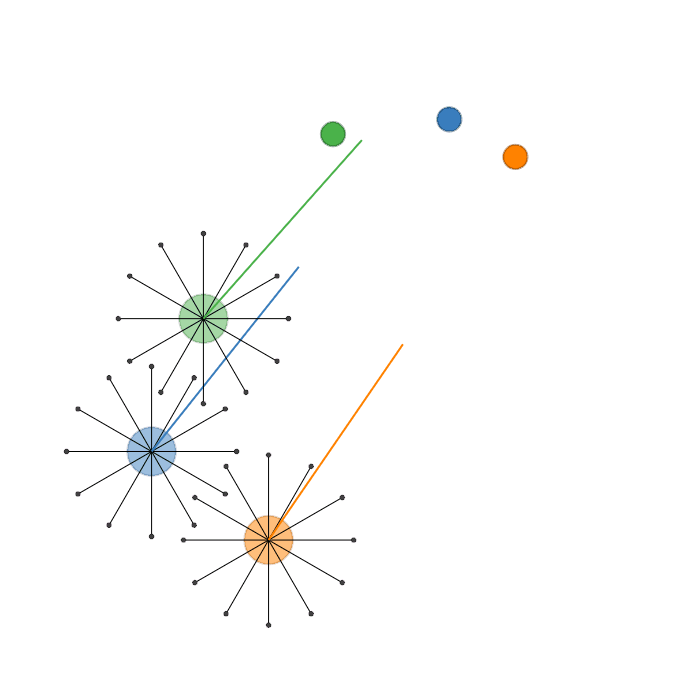

In [ ]:
import pyvirtualdisplay
display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
display.start()
from PIL import Image

def rendering_callback(env, td):
    env.frames.append(Image.fromarray(env.render(mode="rgb_array")))
env.frames = []
with torch.no_grad():
   env.rollout(
       max_steps=max_steps,
       policy=policy,
       callback=rendering_callback,
       auto_cast_to_device=True,
       break_when_any_done=False,
   )
env.frames[0].save(
    f"{scenario_name}.gif",
    save_all=True,
    append_images=env.frames[1:],
   duration=3,
   loop=0,
)

from IPython.display import Image
Image(open(f"{scenario_name}.gif", "rb").read())

# Controlled CTDE Comparison: MADDPG, IDDPG, MAPPO, and IPPO

This section implements the project's controlled comparison directly. It uses:

- the same VMAS Navigation task for all methods,
- the same environment-frame budget for all methods,
- three random seeds,
- decentralized, parameter-shared actors in every method,
- centralized critics for MADDPG/MAPPO and decentralized critics for IDDPG/IPPO,
- mean ± one standard deviation learning curves against **environment frames**,
- deterministic/no-extra-noise final evaluation with team and per-agent returns,
- representative evaluation GIFs.

The interaction budget is deliberately moderate so the full four-method, three-seed experiment can be run in a notebook session. The number of gradient updates is algorithm-specific and is reported separately from the environment-frame budget.


In [33]:
# Imports used only by the controlled comparison.
import gc
import math
import random
import tempfile
import numpy as np
import pandas as pd

try:
    from torchrl.envs.utils import ExplorationType, set_exploration_type
except ImportError:
    from torchrl.envs import ExplorationType, set_exploration_type

# Controlled experiment configuration.
CTDE_SEEDS = [0, 1, 2]
CTDE_FRAMES_PER_BATCH = 6_000
CTDE_TOTAL_FRAMES = 120_000
CTDE_MAX_STEPS = 100
CTDE_N_AGENTS = 3
CTDE_SCENARIO = "navigation"
CTDE_MINIBATCH_SIZE = 400

# Algorithm-specific optimization work per collected batch.
CTDE_DDPG_UPDATES_PER_BATCH = 30
CTDE_PPO_EPOCHS = 10

CTDE_LR = 3e-4
CTDE_GAMMA = 0.99
CTDE_LAMBDA = 0.9
CTDE_CLIP_EPS = 0.2
CTDE_ENTROPY_EPS = 1e-4
CTDE_MAX_GRAD_NORM = 1.0
CTDE_POLYAK_TAU = 0.005
CTDE_REPLAY_CAPACITY = CTDE_TOTAL_FRAMES
CTDE_SIGMA_INIT = 0.5
CTDE_SIGMA_END = 0.1
CTDE_EVAL_EPISODES = 20

assert CTDE_TOTAL_FRAMES % CTDE_FRAMES_PER_BATCH == 0
assert CTDE_FRAMES_PER_BATCH % CTDE_MINIBATCH_SIZE == 0
CTDE_N_ITERS = CTDE_TOTAL_FRAMES // CTDE_FRAMES_PER_BATCH

print("Controlled CTDE configuration")
print("  seeds:", CTDE_SEEDS)
print("  environment frames per run:", f"{CTDE_TOTAL_FRAMES:,}")
print("  frames per batch:", f"{CTDE_FRAMES_PER_BATCH:,}")
print("  batches per run:", CTDE_N_ITERS)
print("  DDPG replay updates per batch:", CTDE_DDPG_UPDATES_PER_BATCH)
print("  PPO epochs per batch:", CTDE_PPO_EPOCHS)
print("  PPO minibatches per epoch:", CTDE_FRAMES_PER_BATCH // CTDE_MINIBATCH_SIZE)

Controlled CTDE configuration
  seeds: [0, 1, 2]
  environment frames per run: 120,000
  frames per batch: 6,000
  batches per run: 20
  DDPG replay updates per batch: 30
  PPO epochs per batch: 10
  PPO minibatches per epoch: 15


In [34]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_navigation_env(num_envs, seed, transformed=True):
    """Create the exact same VMAS Navigation task for every controlled run."""
    seed_everything(seed)
    base_env = VmasEnv(
        scenario=CTDE_SCENARIO,
        num_envs=num_envs,
        continuous_actions=True,
        max_steps=CTDE_MAX_STEPS,
        device=vmas_device,
        n_agents=CTDE_N_AGENTS,
    )
    try:
        base_env.set_seed(seed)
    except Exception:
        pass

    if not transformed:
        return base_env

    return TransformedEnv(
        base_env,
        RewardSum(
            in_keys=[base_env.reward_key],
            out_keys=[("agents", "episode_reward")],
        ),
    )


def expand_agent_done_flags(td):
    """Expand environment-level done/terminated flags to the per-agent reward shape."""
    reward_shape = td.get(("next", "agents", "reward")).shape
    td.set(
        ("next", "agents", "done"),
        td.get(("next", "done")).unsqueeze(-1).expand(reward_shape),
    )
    td.set(
        ("next", "agents", "terminated"),
        td.get(("next", "terminated")).unsqueeze(-1).expand(reward_shape),
    )
    return td


def mean_completed_episode_return(td):
    done = td.get(("next", "agents", "done"))
    if not done.any():
        return float("nan")
    return (
        td.get(("next", "agents", "episode_reward"))[done]
        .mean()
        .item()
    )


def evaluate_policy(policy, seed, n_episodes=CTDE_EVAL_EPISODES):
    """Noise-free/deterministic evaluation; returns team and per-agent returns."""
    eval_env = make_navigation_env(n_episodes, seed + 10_000, transformed=False)
    policy.eval()
    with torch.no_grad(), set_exploration_type(ExplorationType.DETERMINISTIC):
        td = eval_env.rollout(
            max_steps=CTDE_MAX_STEPS,
            policy=policy,
            break_when_any_done=False,
            auto_cast_to_device=True,
        )

    # [episodes, time, agents, 1] -> [episodes, agents]
    rewards = td.get(("next", "agents", "reward"))
    episode_agent_returns = rewards.sum(dim=1).squeeze(-1).detach().cpu()
    episode_team_returns = episode_agent_returns.sum(dim=-1)

    result = {
        "team_return_mean": float(episode_team_returns.mean()),
        "team_return_std": float(episode_team_returns.std(unbiased=False)),
        "per_agent_return_mean": episode_agent_returns.mean(dim=0).tolist(),
        "per_agent_return_std": episode_agent_returns.std(dim=0, unbiased=False).tolist(),
    }
    try:
        eval_env.close()
    except Exception:
        pass
    return result

## Controlled DDPG-family trainer

`centralised=True` gives MADDPG: the critic conditions on all agents' observation-action features. `centralised=False` gives IDDPG: each critic output uses only the corresponding agent's local observation-action features. The actor remains local and parameter-shared in both cases.


In [35]:
def train_ddpg_family(centralised, seed, keep_policy=False):
    label = "MADDPG" if centralised else "IDDPG"
    seed_everything(seed)
    train_env = make_navigation_env(
        CTDE_FRAMES_PER_BATCH // CTDE_MAX_STEPS,
        seed,
        transformed=True,
    )

    obs_dim = train_env.observation_spec["agents", "observation"].shape[-1]
    act_dim = train_env.full_action_spec["agents", "action"].shape[-1]

    # Decentralized, parameter-shared deterministic actor.
    actor_net = MultiAgentMLP(
        n_agent_inputs=obs_dim,
        n_agent_outputs=act_dim,
        n_agents=CTDE_N_AGENTS,
        centralised=False,
        share_params=True,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    )
    actor_module = TensorDictModule(
        actor_net,
        in_keys=[("agents", "observation")],
        out_keys=[("agents", "param")],
    )
    actor = ProbabilisticActor(
        module=actor_module,
        spec=train_env.full_action_spec["agents", "action"],
        in_keys=[("agents", "param")],
        out_keys=[("agents", "action")],
        distribution_class=TanhDelta,
        distribution_kwargs={
            "low": train_env.full_action_spec_unbatched["agents", "action"].space.low,
            "high": train_env.full_action_spec_unbatched["agents", "action"].space.high,
        },
        return_log_prob=False,
    )

    # Exploration belongs only to the collector policy, never to DDPGLoss.
    exploration_policy = TensorDictSequential(
        actor,
        AdditiveGaussianModule(
            spec=actor.spec,
            annealing_num_steps=CTDE_TOTAL_FRAMES // 2,
            action_key=train_env.action_key,
            sigma_init=CTDE_SIGMA_INIT,
            sigma_end=CTDE_SIGMA_END,
        ),
    )

    # Critic: only this centralised switch differs between MADDPG and IDDPG.
    cat_module = TensorDictModule(
        module=lambda obs, action: torch.cat([obs, action], dim=-1),
        in_keys=[("agents", "observation"), ("agents", "action")],
        out_keys=[("agents", "obs_action")],
    )
    critic_module = TensorDictModule(
        module=MultiAgentMLP(
            n_agent_inputs=obs_dim + act_dim,
            n_agent_outputs=1,
            n_agents=CTDE_N_AGENTS,
            centralised=centralised,
            share_params=True,
            device=device,
            depth=2,
            num_cells=256,
            activation_class=torch.nn.Tanh,
        ),
        in_keys=[("agents", "obs_action")],
        out_keys=[("agents", "state_action_value")],
    )
    critic = TensorDictSequential(cat_module, critic_module)

    # Required tensor-shape demonstration.
    if seed == CTDE_SEEDS[0]:
        with torch.no_grad():
            td0 = train_env.reset()
            td_actor = actor(td0.clone())
            td_critic = critic(td_actor.clone())
        print(f"{label} shape check")
        print("  local observation:", td0.get(("agents", "observation")).shape)
        print("  action:", td_actor.get(("agents", "action")).shape)
        print("  per-agent obs-action:", td_critic.get(("agents", "obs_action")).shape)
        print("  critic output:", td_critic.get(("agents", "state_action_value")).shape)
        print("  actor execution features:", obs_dim)
        print(
            "  effective critic features:",
            CTDE_N_AGENTS * (obs_dim + act_dim) if centralised else obs_dim + act_dim,
        )

    collector = Collector(
        train_env,
        exploration_policy,
        device=device,
        frames_per_batch=CTDE_FRAMES_PER_BATCH,
        total_frames=CTDE_TOTAL_FRAMES,
        exploration_type=ExplorationType.RANDOM,
    )

    tmpdir = tempfile.TemporaryDirectory(prefix=f"{label.lower()}_{seed}_")
    replay = ReplayBuffer(
        storage=LazyMemmapStorage(CTDE_REPLAY_CAPACITY, scratch_dir=tmpdir.name),
        sampler=RandomSampler(),
        batch_size=CTDE_MINIBATCH_SIZE,
    )
    if device.type != "cpu":
        replay.append_transform(lambda x: x.to(device))

    loss_module = DDPGLoss(
        actor_network=actor,
        value_network=critic,
        delay_value=True,
        loss_function="l2",
    )
    loss_module.set_keys(
        state_action_value=("agents", "state_action_value"),
        reward=("agents", "reward"),
        done=("agents", "done"),
        terminated=("agents", "terminated"),
    )
    loss_module.make_value_estimator(ValueEstimators.TD0, gamma=CTDE_GAMMA)
    target_updater = SoftUpdate(loss_module, tau=CTDE_POLYAK_TAU)

    actor_optim = torch.optim.Adam(
        loss_module.actor_network_params.flatten_keys().values(), lr=CTDE_LR
    )
    critic_optim = torch.optim.Adam(
        loss_module.value_network_params.flatten_keys().values(), lr=CTDE_LR
    )

    history = {
        "frames": [],
        "episode_reward": [],
        "loss_actor": [],
        "loss_value": [],
        "actor_grad_norm": [],
        "critic_grad_norm": [],
        "exploration_sigma": [],
    }
    frames_seen = 0
    pbar = tqdm(total=CTDE_N_ITERS, desc=f"{label} seed={seed}", leave=False)

    for batch in collector:
        current_frames = batch.numel()
        frames_seen += current_frames
        expand_agent_done_flags(batch)
        replay.extend(batch.reshape(-1))

        actor_losses, critic_losses = [], []
        actor_grad_norms, critic_grad_norms = [], []

        for _ in range(CTDE_DDPG_UPDATES_PER_BATCH):
            subdata = replay.sample()
            loss_vals = loss_module(subdata)
            actor_loss = loss_vals["loss_actor"]
            critic_loss = loss_vals["loss_value"]

            actor_optim.zero_grad(set_to_none=True)
            critic_optim.zero_grad(set_to_none=True)
            (actor_loss + critic_loss).backward()

            actor_grad = torch.nn.utils.clip_grad_norm_(
                actor_optim.param_groups[0]["params"], CTDE_MAX_GRAD_NORM
            )
            critic_grad = torch.nn.utils.clip_grad_norm_(
                critic_optim.param_groups[0]["params"], CTDE_MAX_GRAD_NORM
            )
            actor_optim.step()
            critic_optim.step()
            target_updater.step()

            actor_losses.append(float(actor_loss.detach().cpu()))
            critic_losses.append(float(critic_loss.detach().cpu()))
            actor_grad_norms.append(float(actor_grad.detach().cpu()))
            critic_grad_norms.append(float(critic_grad.detach().cpu()))

        collector.update_policy_weights_()
        exploration_policy[-1].step(current_frames)
        sigma = float(exploration_policy[-1].sigma.detach().cpu())

        history["frames"].append(frames_seen)
        history["episode_reward"].append(mean_completed_episode_return(batch))
        history["loss_actor"].append(float(np.mean(actor_losses)))
        history["loss_value"].append(float(np.mean(critic_losses)))
        history["actor_grad_norm"].append(float(np.mean(actor_grad_norms)))
        history["critic_grad_norm"].append(float(np.mean(critic_grad_norms)))
        history["exploration_sigma"].append(sigma)

        pbar.set_postfix(
            ret=f"{history['episode_reward'][-1]:.2f}",
            qloss=f"{history['loss_value'][-1]:.3f}",
            sigma=f"{sigma:.2f}",
        )
        pbar.update(1)

    pbar.close()
    evaluation = evaluate_policy(actor, seed)
    saved_actor = copy.deepcopy(actor).eval() if keep_policy else None

    try:
        collector.shutdown()
    except Exception:
        pass
    try:
        train_env.close()
    except Exception:
        pass
    del replay, loss_module, critic
    tmpdir.cleanup()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, evaluation, saved_actor

## Controlled PPO-family trainer

`centralised=True` gives MAPPO and `centralised=False` gives IPPO. In both cases the stochastic actor is decentralized and parameter-shared; only the value critic's training-time inputs change.


In [36]:
def train_ppo_family(centralised, seed, keep_policy=False):
    label = "MAPPO" if centralised else "IPPO"
    seed_everything(seed)
    train_env = make_navigation_env(
        CTDE_FRAMES_PER_BATCH // CTDE_MAX_STEPS,
        seed,
        transformed=True,
    )

    obs_dim = train_env.observation_spec["agents", "observation"].shape[-1]
    act_dim = train_env.full_action_spec[train_env.action_key].shape[-1]

    actor_net = torch.nn.Sequential(
        MultiAgentMLP(
            n_agent_inputs=obs_dim,
            n_agent_outputs=2 * act_dim,
            n_agents=CTDE_N_AGENTS,
            centralised=False,
            share_params=True,
            device=device,
            depth=2,
            num_cells=256,
            activation_class=torch.nn.Tanh,
        ),
        NormalParamExtractor(),
    )
    actor_module = TensorDictModule(
        actor_net,
        in_keys=[("agents", "observation")],
        out_keys=[("agents", "loc"), ("agents", "scale")],
    )
    actor = ProbabilisticActor(
        module=actor_module,
        spec=train_env.action_spec_unbatched,
        in_keys=[("agents", "loc"), ("agents", "scale")],
        out_keys=[train_env.action_key],
        distribution_class=TanhNormal,
        distribution_kwargs={
            "low": train_env.full_action_spec_unbatched[train_env.action_key].space.low,
            "high": train_env.full_action_spec_unbatched[train_env.action_key].space.high,
        },
        return_log_prob=True,
    )

    critic = TensorDictModule(
        module=MultiAgentMLP(
            n_agent_inputs=obs_dim,
            n_agent_outputs=1,
            n_agents=CTDE_N_AGENTS,
            centralised=centralised,
            share_params=True,
            device=device,
            depth=2,
            num_cells=256,
            activation_class=torch.nn.Tanh,
        ),
        in_keys=[("agents", "observation")],
        out_keys=[("agents", "state_value")],
    )

    collector = Collector(
        train_env,
        actor,
        device=vmas_device,
        storing_device=device,
        frames_per_batch=CTDE_FRAMES_PER_BATCH,
        total_frames=CTDE_TOTAL_FRAMES,
        exploration_type=ExplorationType.RANDOM,
    )

    loss_module = ClipPPOLoss(
        actor_network=actor,
        critic_network=critic,
        clip_epsilon=CTDE_CLIP_EPS,
        entropy_coeff=CTDE_ENTROPY_EPS,
        normalize_advantage=False,
    )
    loss_module.set_keys(
        reward=train_env.reward_key,
        action=train_env.action_key,
        value=("agents", "state_value"),
        done=("agents", "done"),
        terminated=("agents", "terminated"),
    )
    loss_module.make_value_estimator(
        ValueEstimators.GAE,
        gamma=CTDE_GAMMA,
        lmbda=CTDE_LAMBDA,
    )
    GAE = loss_module.value_estimator
    optim = torch.optim.Adam(loss_module.parameters(), CTDE_LR)

    history = {
        "frames": [],
        "episode_reward": [],
        "loss_objective": [],
        "loss_critic": [],
        "loss_entropy": [],
        "grad_norm": [],
        "kl_approx": [],
        "entropy": [],
    }
    frames_seen = 0
    pbar = tqdm(total=CTDE_N_ITERS, desc=f"{label} seed={seed}", leave=False)

    for iteration, batch in enumerate(collector):
        current_frames = batch.numel()
        frames_seen += current_frames
        expand_agent_done_flags(batch)

        with torch.no_grad():
            GAE(
                batch,
                params=loss_module.critic_network_params,
                target_params=loss_module.target_critic_network_params,
            )

        # Required shape verification once per method.
        if iteration == 0 and seed == CTDE_SEEDS[0]:
            print(f"{label} shape check")
            print("  action:", batch.get(train_env.action_key).shape)
            print("  action log-prob:", batch.get(actor.log_prob_keys[0]).shape)
            print("  state value:", batch.get(loss_module.tensor_keys.value).shape)
            print("  advantage:", batch.get(loss_module.tensor_keys.advantage).shape)
            print("  value target:", batch.get(loss_module.tensor_keys.value_target).shape)
            print("  actor execution features:", obs_dim)
            print("  effective critic features:", CTDE_N_AGENTS * obs_dim if centralised else obs_dim)

        # A fresh static buffer guarantees that every PPO epoch uses only this batch.
        on_policy_buffer = ReplayBuffer(
            storage=LazyTensorStorage(CTDE_FRAMES_PER_BATCH, device=device),
            sampler=SamplerWithoutReplacement(drop_last=True),
            batch_size=CTDE_MINIBATCH_SIZE,
        )
        on_policy_buffer.extend(batch.reshape(-1))

        objective_losses, critic_losses, entropy_losses = [], [], []
        grad_norms, kl_values, entropy_values = [], [], []

        for _ in range(CTDE_PPO_EPOCHS):
            for _ in range(CTDE_FRAMES_PER_BATCH // CTDE_MINIBATCH_SIZE):
                subdata = on_policy_buffer.sample()
                loss_vals = loss_module(subdata)
                total_loss = (
                    loss_vals["loss_objective"]
                    + loss_vals["loss_critic"]
                    + loss_vals["loss_entropy"]
                )

                optim.zero_grad(set_to_none=True)
                total_loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(
                    loss_module.parameters(), CTDE_MAX_GRAD_NORM
                )
                optim.step()

                objective_losses.append(float(loss_vals["loss_objective"].detach().cpu()))
                critic_losses.append(float(loss_vals["loss_critic"].detach().cpu()))
                entropy_losses.append(float(loss_vals["loss_entropy"].detach().cpu()))
                grad_norms.append(float(grad_norm.detach().cpu()))
                if "kl_approx" in loss_vals.keys():
                    kl_values.append(float(loss_vals["kl_approx"].detach().mean().cpu()))
                if "entropy" in loss_vals.keys():
                    entropy_values.append(float(loss_vals["entropy"].detach().mean().cpu()))

        collector.update_policy_weights_()

        history["frames"].append(frames_seen)
        history["episode_reward"].append(mean_completed_episode_return(batch))
        history["loss_objective"].append(float(np.mean(objective_losses)))
        history["loss_critic"].append(float(np.mean(critic_losses)))
        history["loss_entropy"].append(float(np.mean(entropy_losses)))
        history["grad_norm"].append(float(np.mean(grad_norms)))
        history["kl_approx"].append(float(np.mean(kl_values)) if kl_values else float("nan"))
        history["entropy"].append(float(np.mean(entropy_values)) if entropy_values else float("nan"))

        pbar.set_postfix(
            ret=f"{history['episode_reward'][-1]:.2f}",
            kl=f"{history['kl_approx'][-1]:.4f}",
            ent=f"{history['entropy'][-1]:.2f}",
        )
        pbar.update(1)

    pbar.close()
    evaluation = evaluate_policy(actor, seed)
    saved_actor = copy.deepcopy(actor).eval() if keep_policy else None

    try:
        collector.shutdown()
    except Exception:
        pass
    try:
        train_env.close()
    except Exception:
        pass
    del loss_module, critic
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, evaluation, saved_actor

## Run all four methods over matched seeds

This is the main experiment. It will take substantially longer than a single training run because it trains four methods over three seeds. The representative policy retained for each method is seed 0; all reported numerical evaluation statistics still use all seeds.


In [37]:
ctde_results = {}
representative_policies = {}

experiment_plan = [
    ("MADDPG", "ddpg", True),
    ("IDDPG", "ddpg", False),
    ("MAPPO", "ppo", True),
    ("IPPO", "ppo", False),
]

for label, family, centralised in experiment_plan:
    ctde_results[label] = {"histories": [], "evaluations": []}
    for seed in CTDE_SEEDS:
        print(f"\n=== {label} | seed {seed} ===")
        if family == "ddpg":
            history, evaluation, saved_policy = train_ddpg_family(
                centralised=centralised,
                seed=seed,
                keep_policy=(seed == CTDE_SEEDS[0]),
            )
        else:
            history, evaluation, saved_policy = train_ppo_family(
                centralised=centralised,
                seed=seed,
                keep_policy=(seed == CTDE_SEEDS[0]),
            )

        ctde_results[label]["histories"].append(history)
        ctde_results[label]["evaluations"].append(evaluation)
        if saved_policy is not None:
            representative_policies[label] = saved_policy

        print(
            f"final deterministic evaluation: team={evaluation['team_return_mean']:.3f}; "
            f"per-agent={np.round(evaluation['per_agent_return_mean'], 3).tolist()}"
        )

print("\nControlled CTDE experiment complete.")

/tmp/ipykernel_1210/1196573318.py:95: FutureWarning: The env passed to Collector is missing transforms required by the policy (InitTracker). From torchrl v0.15 the collector will append them automatically. To enable that behavior now (and silence this warning), pass `auto_register_policy_transforms=True`. To opt out permanently, pass `auto_register_policy_transforms=False`.
  collector = Collector(



=== MADDPG | seed 0 ===
MADDPG shape check
  local observation: torch.Size([60, 3, 18])
  action: torch.Size([60, 3, 2])
  per-agent obs-action: torch.Size([60, 3, 20])
  critic output: torch.Size([60, 3, 1])
  actor execution features: 18
  effective critic features: 60


MADDPG seed=0:   0%|          | 0/20 [00:00<?, ?it/s]

2026-08-18 20:28:22,664 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([120000]) shape [END]


final deterministic evaluation: team=-10.671; per-agent=[-3.974, -3.174, -3.524]

=== MADDPG | seed 1 ===


...

IPPO seed=2:  90%|█████████ | 18/20 [00:51<00:05,  2.98s/it, ent=1.10, kl=0.0042, ret=2.60]

2026-08-18 20:38:22,324 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([6000]) shape [END]


IPPO seed=2:  95%|█████████▌| 19/20 [00:55<00:03,  3.02s/it, ent=1.13, kl=0.0053, ret=2.44]

2026-08-18 20:38:25,877 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([6000]) shape [END]


final deterministic evaluation: team=8.054; per-agent=[2.651, 2.651, 2.751]

Controlled CTDE experiment complete.


## Learning curves with uncertainty bands

All curves below use the same x-axis: environment interactions. The shaded region is ±1 standard deviation across the three random seeds.


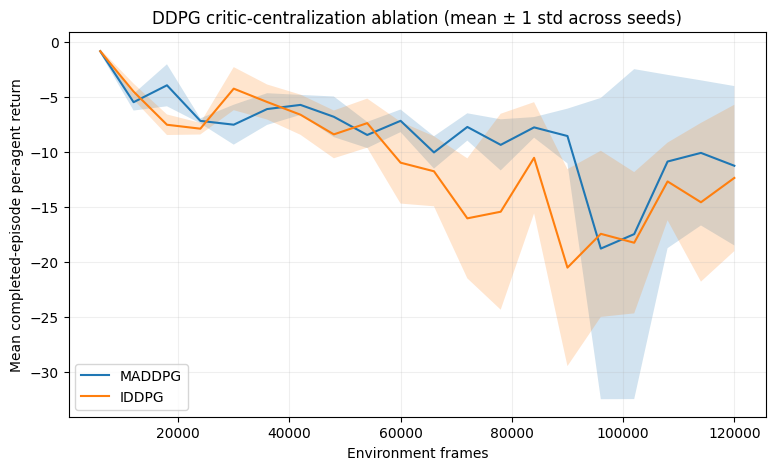

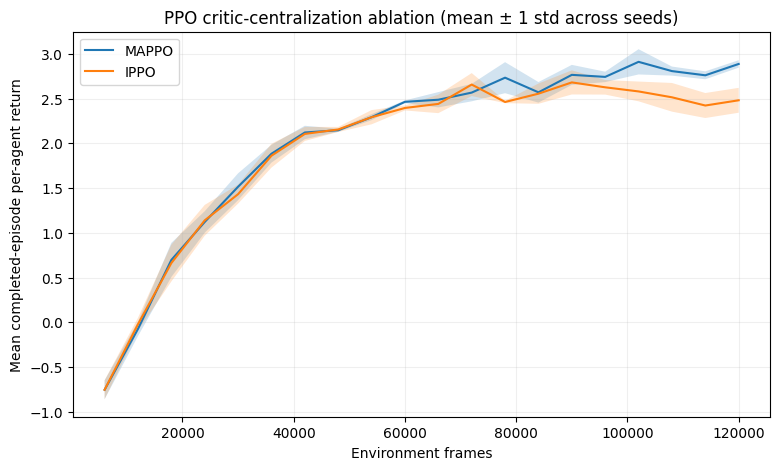

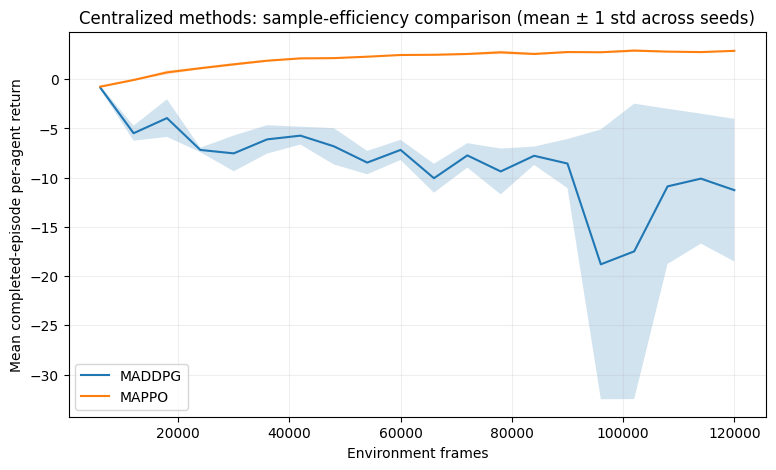

In [38]:
def plot_mean_std(labels, title):
    plt.figure(figsize=(9, 5))
    for label in labels:
        histories = ctde_results[label]["histories"]
        frames = np.asarray(histories[0]["frames"], dtype=float)
        returns = np.asarray([h["episode_reward"] for h in histories], dtype=float)
        mean = np.nanmean(returns, axis=0)
        std = np.nanstd(returns, axis=0)
        plt.plot(frames, mean, label=label)
        plt.fill_between(frames, mean - std, mean + std, alpha=0.2)
    plt.xlabel("Environment frames")
    plt.ylabel("Mean completed-episode per-agent return")
    plt.title(title + " (mean ± 1 std across seeds)")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_mean_std(["MADDPG", "IDDPG"], "DDPG critic-centralization ablation")
plot_mean_std(["MAPPO", "IPPO"], "PPO critic-centralization ablation")
plot_mean_std(["MADDPG", "MAPPO"], "Centralized methods: sample-efficiency comparison")

## Final deterministic evaluation

Each trained seed is evaluated for 20 episodes without MADDPG's Gaussian collector noise and with deterministic action selection for probabilistic policies. The table reports the mean across seeds; `team_return_std_across_seeds` measures seed-to-seed variation in the evaluated team return.


In [39]:
summary_rows = []
for label in ["MADDPG", "IDDPG", "MAPPO", "IPPO"]:
    evaluations = ctde_results[label]["evaluations"]
    team_seed_means = np.asarray([e["team_return_mean"] for e in evaluations])
    per_agent_seed_means = np.asarray([e["per_agent_return_mean"] for e in evaluations])

    row = {
        "algorithm": label,
        "frames_per_seed": CTDE_TOTAL_FRAMES,
        "n_seeds": len(CTDE_SEEDS),
        "team_return_mean": team_seed_means.mean(),
        "team_return_std_across_seeds": team_seed_means.std(ddof=0),
    }
    for agent_idx in range(CTDE_N_AGENTS):
        row[f"agent_{agent_idx}_return_mean"] = per_agent_seed_means[:, agent_idx].mean()
    summary_rows.append(row)

ctde_summary = pd.DataFrame(summary_rows).set_index("algorithm")
display(ctde_summary.round(4))

,frames_per_seed,n_seeds,team_return_mean,team_return_std_across_seeds,agent_0_return_mean,agent_1_return_mean,agent_2_return_mean
algorithm,,,,,,,
MADDPG,120000,3,-35.9210,31.3382,-13.1014,-11.2348,-11.5848
IDDPG,120000,3,-35.7494,25.4645,-12.5720,-9.6887,-13.4887
MAPPO,120000,3,12.4969,2.7442,4.1490,4.1156,4.2323
IPPO,120000,3,7.8201,0.4140,2.5956,2.5956,2.6289


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Optimization diagnostics

These plots provide the quantities needed to diagnose unstable periods rather than relying only on the final learning curve.


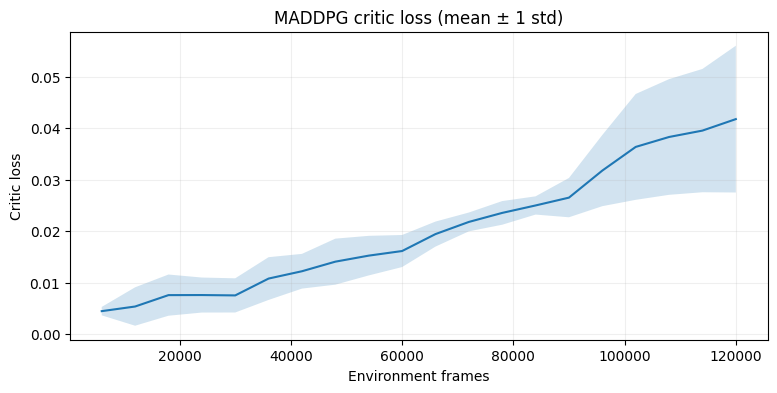

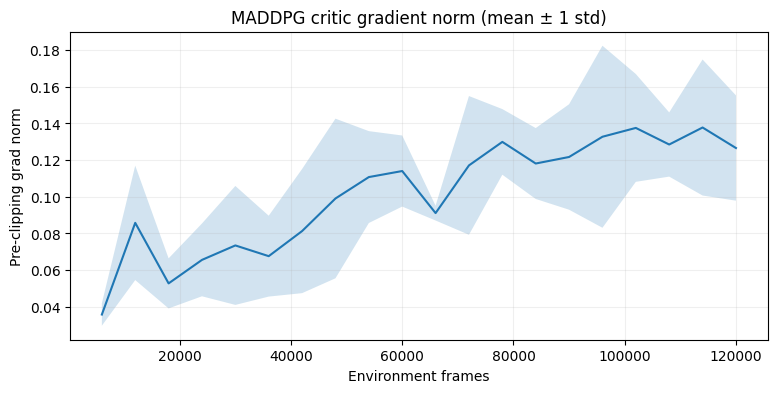

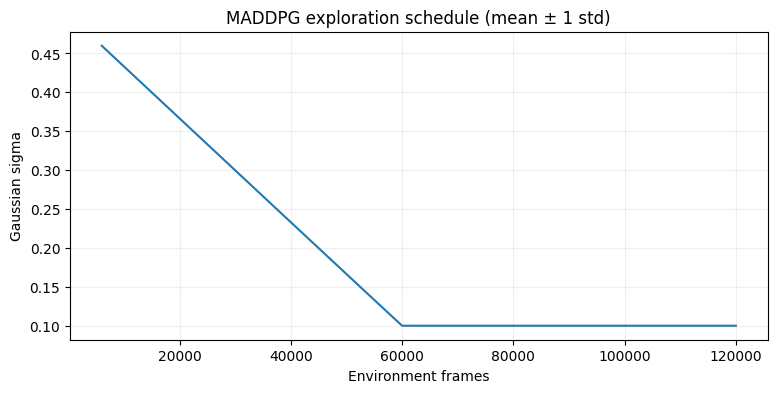

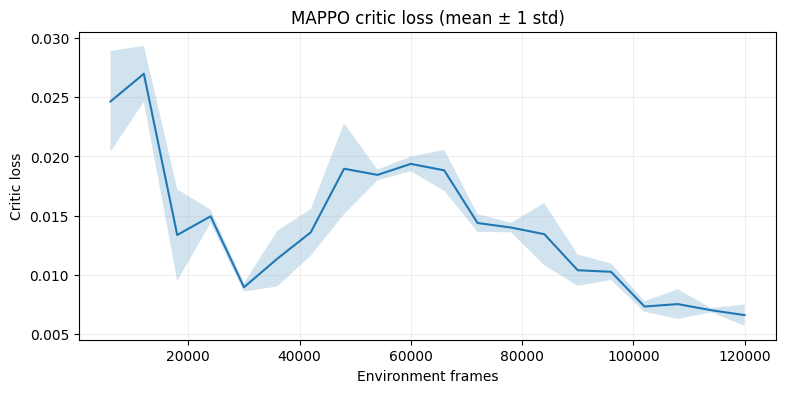

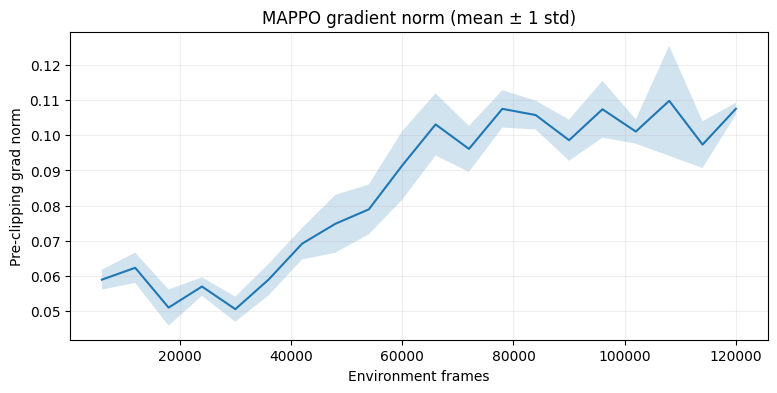

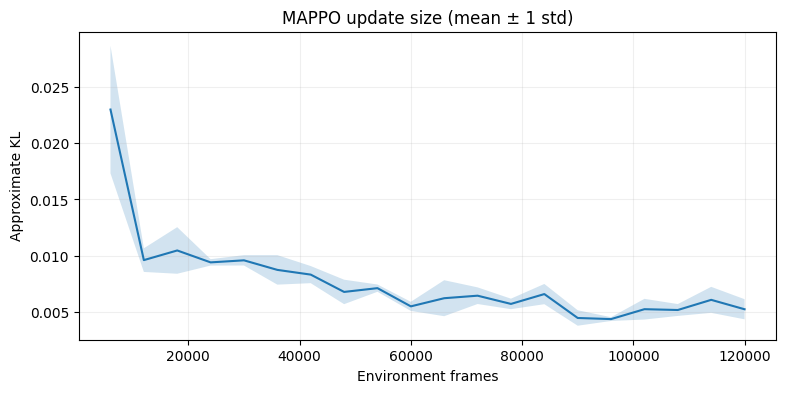

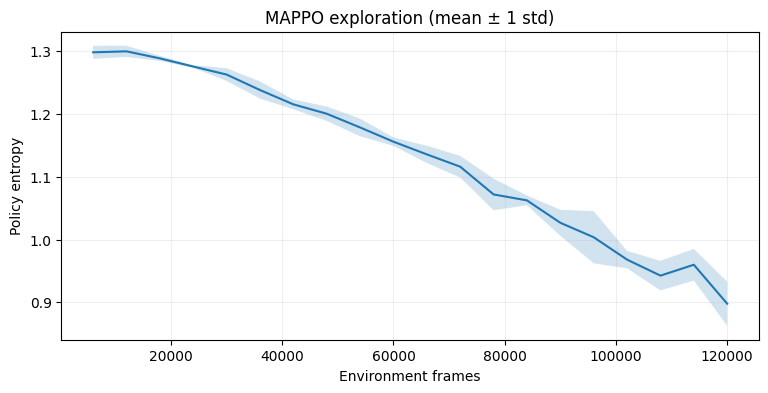

In [40]:
def plot_metric_mean_std(label, metric, ylabel, title):
    histories = ctde_results[label]["histories"]
    frames = np.asarray(histories[0]["frames"], dtype=float)
    values = np.asarray([h[metric] for h in histories], dtype=float)
    mean = np.nanmean(values, axis=0)
    std = np.nanstd(values, axis=0)
    plt.figure(figsize=(9, 4))
    plt.plot(frames, mean)
    plt.fill_between(frames, mean - std, mean + std, alpha=0.2)
    plt.xlabel("Environment frames")
    plt.ylabel(ylabel)
    plt.title(title + " (mean ± 1 std)")
    plt.grid(alpha=0.2)
    plt.show()


plot_metric_mean_std("MADDPG", "loss_value", "Critic loss", "MADDPG critic loss")
plot_metric_mean_std("MADDPG", "critic_grad_norm", "Pre-clipping grad norm", "MADDPG critic gradient norm")
plot_metric_mean_std("MADDPG", "exploration_sigma", "Gaussian sigma", "MADDPG exploration schedule")
plot_metric_mean_std("MAPPO", "loss_critic", "Critic loss", "MAPPO critic loss")
plot_metric_mean_std("MAPPO", "grad_norm", "Pre-clipping grad norm", "MAPPO gradient norm")
plot_metric_mean_std("MAPPO", "kl_approx", "Approximate KL", "MAPPO update size")
plot_metric_mean_std("MAPPO", "entropy", "Policy entropy", "MAPPO exploration")

## Representative evaluation episodes

The following cell renders one deterministic evaluation episode for every method. After execution, inspect the GIFs and record at least one concrete coordination success or failure for the final written response. We will use these rendered episodes together with the numerical results when answering the project questions.


/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacing an existing nn.Parameter in the destination module with a tensor leaf that is not an nn.Parameter. This historical behavior can remove the key from module.state_dict(). In tensordict v0.14, to_module() will preserve existing module parameter and buffer registrations by default. Pass preserve_module_state=False to keep the current replacement behavior, or preserve_module_state=True to opt in to the v0.14 behavior now.
  local_out = _set_tensor_dict(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/tensordict/_td.py:612: FutureWarning: TensorDict.to_module() is replacin

MADDPG


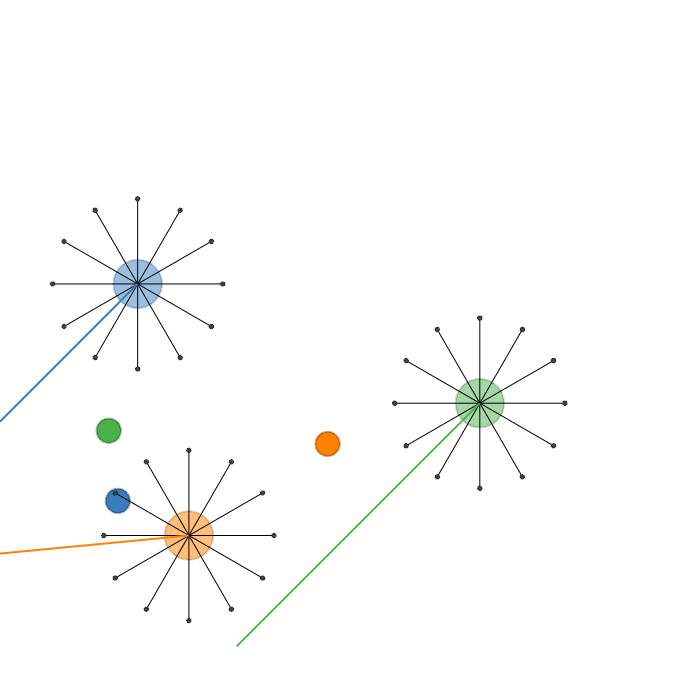

IDDPG


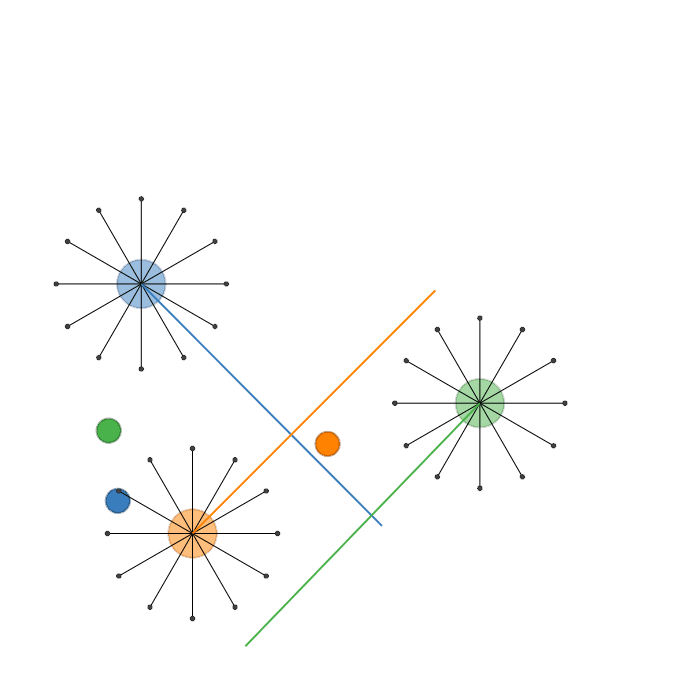

MAPPO


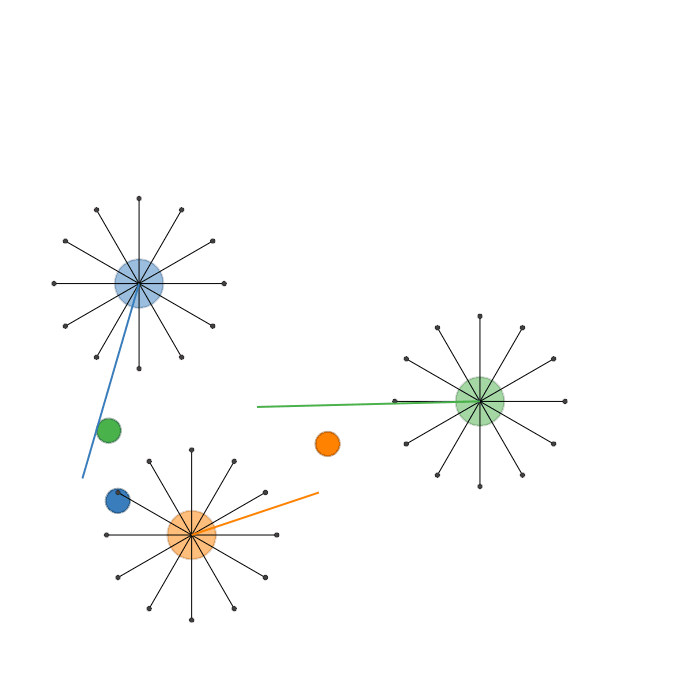

IPPO


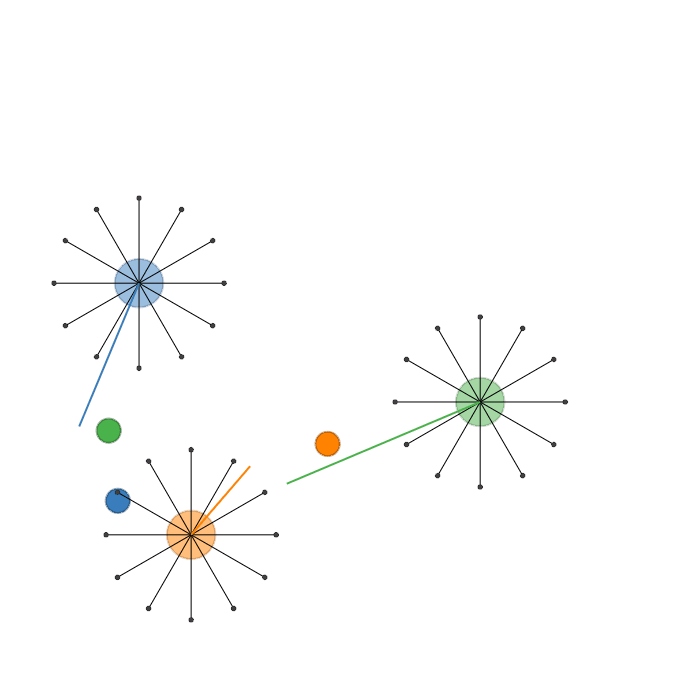

In [41]:
from PIL import Image as PILImage
from IPython.display import Image as IPyImage, display as ipy_display

try:
    import pyvirtualdisplay
    _ctde_display = pyvirtualdisplay.Display(visible=False, size=(1400, 900))
    _ctde_display.start()
except Exception:
    _ctde_display = None


def render_representative(policy, label, seed=123):
    render_env = make_navigation_env(1, seed, transformed=False)
    render_env.frames = []

    def callback(env, td):
        env.frames.append(PILImage.fromarray(env.render(mode="rgb_array")))

    with torch.no_grad(), set_exploration_type(ExplorationType.DETERMINISTIC):
        render_env.rollout(
            max_steps=CTDE_MAX_STEPS,
            policy=policy,
            callback=callback,
            auto_cast_to_device=True,
            break_when_any_done=False,
        )

    filename = f"{label.lower()}_navigation_eval.gif"
    render_env.frames[0].save(
        filename,
        save_all=True,
        append_images=render_env.frames[1:],
        duration=50,
        loop=0,
    )
    try:
        render_env.close()
    except Exception:
        pass
    return filename


ctde_gifs = {}
for label in ["MADDPG", "IDDPG", "MAPPO", "IPPO"]:
    gif_path = render_representative(representative_policies[label], label)
    ctde_gifs[label] = gif_path
    print(label)
    ipy_display(IPyImage(filename=gif_path))

# Questions
1. Why does MAPPO typically converge faster and more stably than MADDPG, while MADDPG often shows slow or unstable improvement in early training?

2. Why is MADDPG generally more sample efficient than MAPPO?

3. What failure modes emerge in MAPPO if the critic becomes fully decentralized while the policy remains stochastic and shared across agents?
4. What is the difference between IDDPG vs MADDPG and IPPO vs MAPPO?


## Notebook Questions

### 1. Why is MAPPO usually more stable than MADDPG?

MAPPO uses stochastic exploration, PPO clipping, GAE, and fresh on-policy data. These make the updates more stable.

MADDPG uses replay and bootstrapped Q-values. In multi-agent training, old replay data can become stale because the other agents keep changing.

In our results, MAPPO improved smoothly, while MADDPG was unstable and its return dropped strongly near the end.

### 2. Why can MADDPG be more sample efficient?

MADDPG can reuse each transition many times from the replay buffer. So it can make many gradient updates without collecting new samples.

MAPPO uses each on-policy batch only for a few epochs and then needs new data.

However, in our experiment, MAPPO was actually better within the same 120k-frame budget because MADDPG was unstable.

### 3. What happens if MAPPO uses a decentralized critic?

MAPPO uses a centralized critic:

$$
V_i(o_1,\ldots,o_n)
$$

while IPPO uses only local information:

$$
V_i(o_i)
$$

A local critic has less information, so value estimates and advantages can become noisier. This also makes credit project harder.

Our results support this: MAPPO reached a team return of about **12.50**, while IPPO reached about **7.82**.

### 4. MADDPG vs. IDDPG and MAPPO vs. IPPO

The main difference is the critic input.

MADDPG uses:

$$
Q_i(o_1,\ldots,o_n,a_1,\ldots,a_n)
$$

while IDDPG uses:

$$
Q_i(o_i,a_i)
$$

MAPPO uses:

$$
V_i(o_1,\ldots,o_n)
$$

while IPPO uses:

$$
V_i(o_i)
$$

The actors are still decentralized in all cases, so execution-time information does not change.

---

# project Question 1 — Stability vs. Sample Efficiency

### 1. Why can MAPPO learn more smoothly?

MAPPO uses stochastic exploration, PPO clipping, GAE, and fresh on-policy data. These reduce large or noisy updates.

MADDPG uses deterministic policies, replay, and bootstrapped Q-targets. Old replay data can become less useful as the other agents change.

In our runs, MAPPO learned smoothly, while MADDPG stayed unstable under the same 120k-frame budget.

### 2. Why can MADDPG still be sample efficient?

MADDPG reuses old transitions from the replay buffer, so one environment interaction can be used in many updates.

MAPPO needs fresh data after a limited number of PPO epochs.

So MADDPG can be more sample efficient when training is stable. In our experiment, this advantage did not appear because MADDPG was unstable.

### 3. Example of an unstable period

MADDPG became unstable around **90k–102k frames**. Its return dropped strongly, while critic loss and critic gradient norm increased.

This suggests that the Q-function became inaccurate. Because the actor learns directly from the critic, bad Q-values can also produce bad policy updates.

MAPPO was more stable: its critic loss decreased and its KL stayed small.

---

# project Question 2 — Centralization and Credit project

### 1. Centralized vs. decentralized critics

For MADDPG:

$$
Q_i(o_1,\ldots,o_n,a_1,\ldots,a_n)
$$

For IDDPG:

$$
Q_i(o_i,a_i)
$$

For MAPPO:

$$
V_i(o_1,\ldots,o_n)
$$

For IPPO:

$$
V_i(o_i)
$$

Only the critic information changes. The actors still use only local observations during execution.

### 2. Why can a decentralized MAPPO critic be worse?

A local critic cannot see the full state of the team. This can cause:

* worse credit project,
* noisier value estimates,
* higher advantage variance,
* noisier shared-policy updates.

Our results show this clearly: MAPPO reached about **12.50** team return, while IPPO reached about **7.82**.

### 3. What did centralization change in our experiment?

For PPO, centralization clearly improved performance:

* MAPPO: **12.50**
* IPPO: **7.82**

However, MAPPO had larger variation across seeds, so centralization improved the mean return but not the variance.

For DDPG:

* MADDPG: **-35.92**
* IDDPG: **-35.75**

Both performed poorly at 120k frames, so we cannot make a strong conclusion about centralization for DDPG.

Also, the centralized critic has a larger input size, so the difference cannot be explained only by CTDE.
